<a href="https://colab.research.google.com/github/psept77-star/Heart_Disease_Prediction/blob/main/Heart_disease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn import preprocessing
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Step 2 Loading and Handling Missing Values from the dataset
disease_df = pd.read_csv('/content/sample_data/framingham.csv')
disease_df.drop(columns=['education'], inplace = True, axis = 1)
disease_df.rename(columns={'male':'Sex_male'}, inplace = True)

In [3]:
disease_df.dropna(axis = 0, inplace = True)
disease_df

,Sex_male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4237,0,52,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0


In [4]:
#Step 3 : Splitting the Dataset into Test and Train sets
X = np.asarray(disease_df[['age', 'Sex_male', 'cigsPerDay', 'totChol', 'sysBP', 'glucose']])

y = np.asarray(disease_df['TenYearCHD'])

X = preprocessing.StandardScaler().fit(X).transform(X)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 4)

print("Train set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

Train set: (2625, 6) (2625,)
Test set: (1126, 6) (1126,)


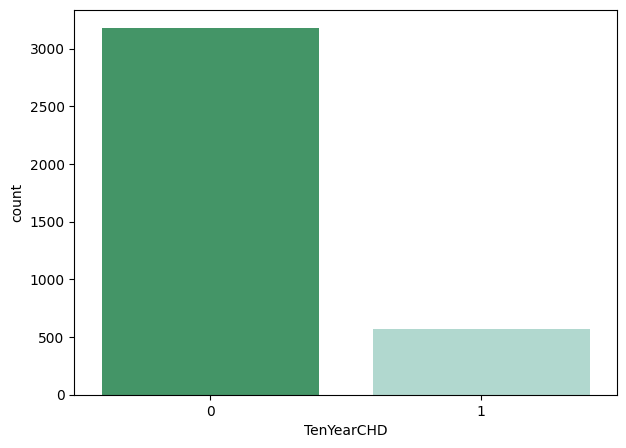

In [7]:
# Step 4 : Exploratory Data Analysis of Heart Disease dataset
# Ten year's CHD Record of all the patients available in the dataset
plt.figure(figsize=(7, 5))
sns.countplot(x='TenYearCHD', data=disease_df, hue = 'TenYearCHD', palette='BuGn_r', legend=False)
plt.show()


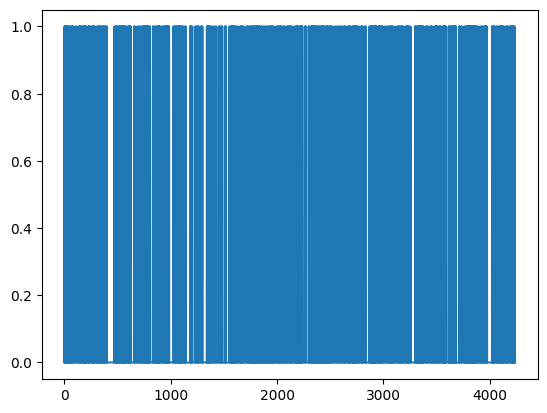

In [8]:
# Counting number of patients affected by CHD where (0=Not affected, 1= Affected)
laste = disease_df['TenYearCHD'].plot()
plt.show(laste)

In [9]:
# Step 5 Fitting Logistic regression model for Heart Disease Predition
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

In [10]:
# Step 6 Evaluating Logistic Regression Model
from sklearn.metrics import accuracy_score
print("Accuracy of the model is =", accuracy_score(y_test, y_pred))

Accuracy of the model is = 0.8490230905861457


The details for confusion matrix is =
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       951
           1       0.61      0.08      0.14       175

    accuracy                           0.85      1126
   macro avg       0.73      0.54      0.53      1126
weighted avg       0.82      0.85      0.80      1126



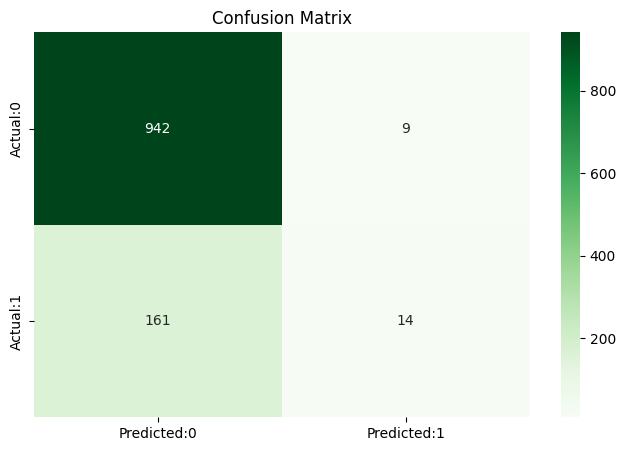

In [12]:
# Plotting Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report

print("The details for confusion matrix is =")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
conf_matrix = pd.DataFrame(data = cm, columns = ['Predicted:0', 'Predicted:1'], index = ['Actual:0', 'Actual:1'])
plt.figure(figsize=(8, 5))
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = 'Greens')
plt.title('Confusion Matrix')
plt.show()

## Creating a New GitHub Repository

1.  **Go to GitHub:** Open your web browser and navigate to [github.com](https://github.com).
2.  **Sign in:** Log in to your GitHub account. If you don't have one, you'll need to create one first.
3.  **Start a new repository:**
    *   On the GitHub homepage, look for a green button labeled "New" or a "+" icon in the top right corner (next to your profile picture), and select "New repository" from the dropdown.
4.  **Repository name:** Choose a name for your repository (e.g., `heart-disease-prediction`). This will be the name of your project on GitHub.
5.  **Description (optional):** Add a short description of your project.
6.  **Public or Private:** Choose whether the repository should be public (visible to everyone) or private (only visible to you and people you share it with).
7.  **Initialize with a README (optional but recommended):** Check the box "Add a README file." This file is where you can describe your project in more detail.
8.  **Create repository:** Click the green "Create repository" button.

Once your repository is created, you can then proceed with saving your Colab notebook to it as described before.